In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data load
df = pd.read_csv('Fitbit_dataset.csv')
df.head()

,Unnamed: 0,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Base_MET,HR_Intensity,Effective_MET,Calories_Burned (kcal)
0,0,56,Female,53.8,1.62,163.0,149.0,71.0,1.01,HIIT,22.1,3.5,3,1,20.4,9.5,0.847826,8.054348,437.7
1,1,46,Male,54.9,1.75,170.0,126.0,73.0,0.25,Yoga,19.9,3.4,3,0,18.0,3.0,0.546392,1.639175,22.5
2,2,32,Female,68.5,1.61,190.0,171.0,60.0,0.33,HIIT,20.4,2.7,3,1,26.5,9.5,0.853846,8.111538,183.4
3,3,25,Male,98.8,1.86,189.0,135.0,69.0,0.78,Yoga,30.3,4.4,3,0,28.5,3.0,0.550000,1.650000,127.2
4,4,38,Male,95.5,1.71,176.0,138.0,66.0,0.55,Cardio,23.7,2.2,2,0,32.5,7.0,0.654545,4.581818,240.7


In [2]:
# Basic info
df.shape        
df.info()       
df.describe()   
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 14102 entries, 0 to 14101
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     14102 non-null  int64  
 1   Age                            14102 non-null  int64  
 2   Gender                         14102 non-null  str    
 3   Weight (kg)                    14102 non-null  float64
 4   Height (m)                     14102 non-null  float64
 5   Max_BPM                        14102 non-null  float64
 6   Avg_BPM                        14102 non-null  float64
 7   Resting_BPM                    14102 non-null  float64
 8   Session_Duration (hours)       14102 non-null  float64
 9   Workout_Type                   14102 non-null  str    
 10  Fat_Percentage                 14102 non-null  float64
 11  Water_Intake (liters)          14102 non-null  float64
 12  Workout_Frequency (days/week)  14102 non-null  int64  
 1

Unnamed: 0                       0
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
Base_MET                         0
HR_Intensity                     0
Effective_MET                    0
Calories_Burned (kcal)           0
dtype: int64

In [3]:
df['Workout_Type'].dtype
df['Workout_Type']=df['Workout_Type'].astype(str)
df['Gender']=df['Gender'].astype(str)
df['Gender']=df['Gender'].str.lower()
df['Workout_Type']=df['Workout_Type'].str.lower()

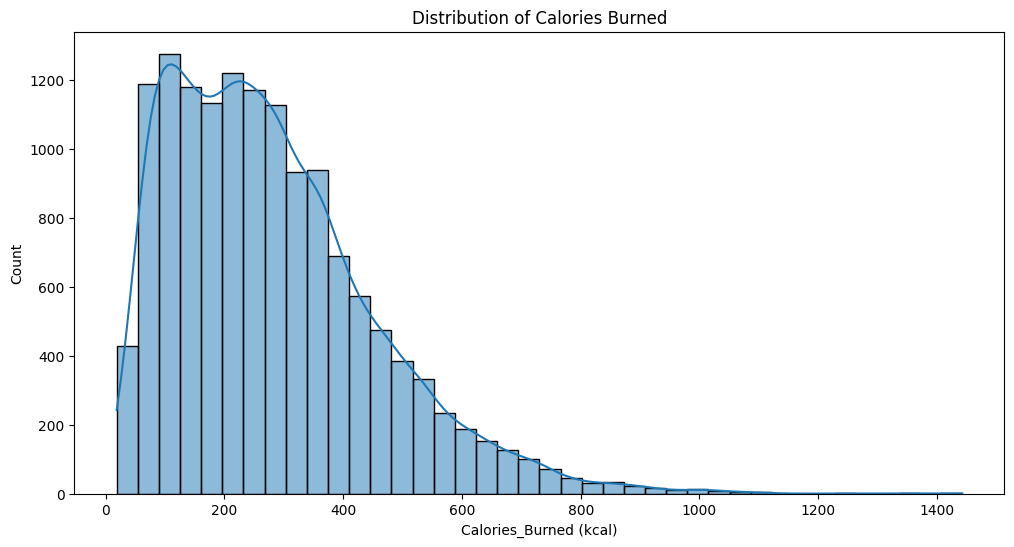

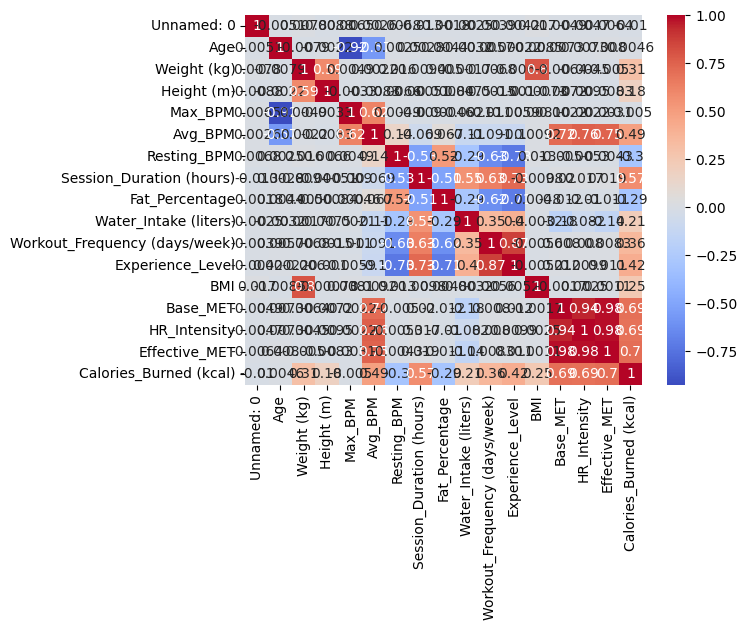

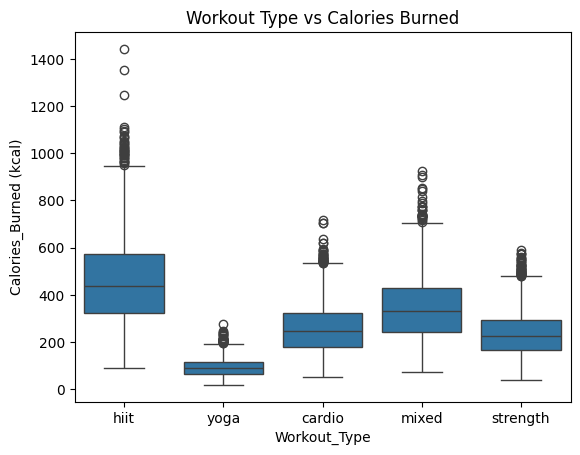

In [4]:


# Visualizations
plt.figure(figsize=(12, 6))
plt.title('Distribution of Calories Burned')
sns.histplot(data=df,
             x='Calories_Burned (kcal)',
             bins=40,
             kde=True)  

# target variable distribution
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

# Workout type vs Calories
sns.boxplot(x='Workout_Type', y='Calories_Burned (kcal)', data=df)
plt.title('Workout Type vs Calories Burned')
plt.show()

In [ ]:
# Missing values handle 
from operator import le


df.fillna(df.median(numeric_only=True), inplace=True)

# Outlier capping (IQR method)
for col in ['Max_BPM', 'Avg_BPM', 'Calories_Burned (kcal)']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Categorical Encoding
encode = LabelEncoder()
df['Gender'] = encode.fit_transform(df['Gender'])          # Male=1, Female=0
df['Workout_Type'] = encode.fit_transform(df['Workout_Type'])
df['Experience_Level'] = encode.fit_transform(df['Experience_Level'])

In [6]:
X = df.drop('Calories_Burned (kcal)', axis=1)  # Features
y = df['Calories_Burned (kcal)']               # Target

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

#we should try multiple models to find the best one for our regression task. Here are some common regression models we can use:

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(),
    'Lasso':             Lasso(),
    'KNN':               KNeighborsRegressor(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(random_state=42),
    'SVR':               SVR(),
    'XGBoost':           XGBRegressor(random_state=42)
}

# we should loop through all models to train and evaluate them
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

# Results table
results_df = pd.DataFrame(results).T

print(results_df.sort_values('R2', ascending=False))

Linear Regression: MAE=31.80, RMSE=45.76, R²=0.9261
Ridge: MAE=31.80, RMSE=45.76, R²=0.9261
Lasso: MAE=32.11, RMSE=46.51, R²=0.9237
KNN: MAE=30.38, RMSE=42.17, R²=0.9373
Decision Tree: MAE=7.85, RMSE=12.30, R²=0.9947
Random Forest: MAE=3.70, RMSE=7.04, R²=0.9982
SVR: MAE=30.09, RMSE=51.60, R²=0.9061
XGBoost: MAE=5.36, RMSE=7.89, R²=0.9978
                         MAE       RMSE        R2
Random Forest       3.698512   7.043140  0.998250
XGBoost             5.359256   7.894908  0.997801
Decision Tree       7.846827  12.296022  0.994666
KNN                30.384137  42.173926  0.937251
Linear Regression  31.795526  45.760626  0.926124
Ridge              31.798752  45.760925  0.926123
Lasso              32.110532  46.513447  0.923674
SVR                30.089110  51.601330  0.906062


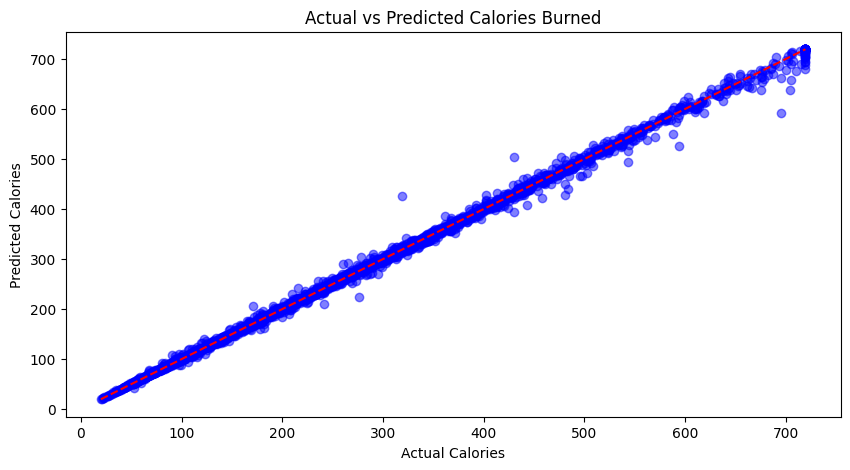

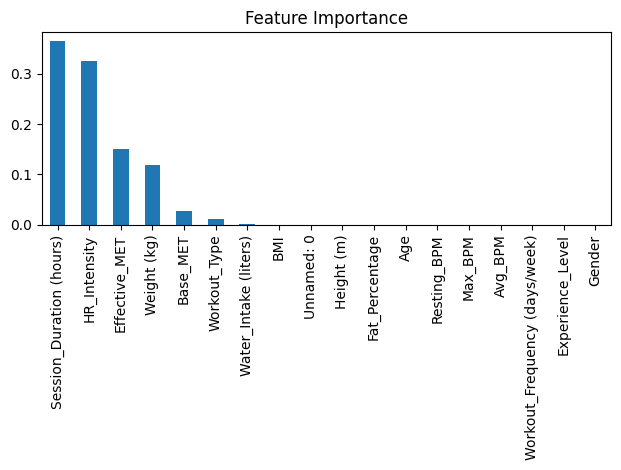

In [8]:
# Best model = Random Forest or XGBoost (usually)
best_model = RandomForestRegressor(random_state=5)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Actual vs Predicted plot
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted Calories Burned')
plt.show()

# Feature Importance
feat_imp = pd.Series(best_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='bar', title='Feature Importance')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# only dropout Workout_Type (should do label  cluster )
df_cluster = df.drop(['Workout_Type', 'Calories_Burned (kcal)'], axis=1)

# Scale 
scaler2 = StandardScaler()
X_scaled = scaler2.fit_transform(df_cluster)


Explained Variance: 44.44%


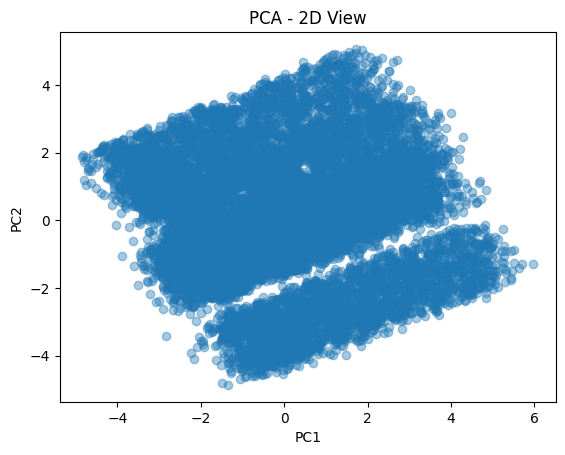

In [10]:
# PCA - Dimensionality Reduction
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

# PCA plot
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - 2D View')
plt.show()

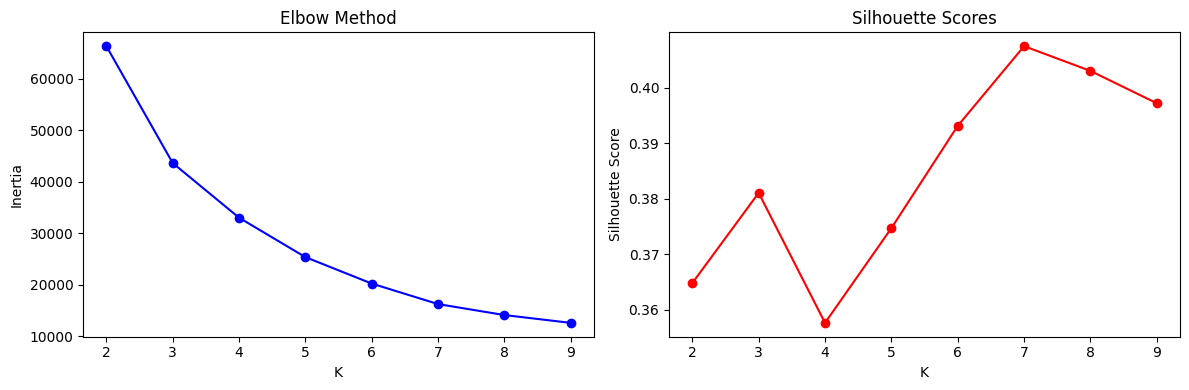

In [11]:
# we should find the optimal K (Elbow method + Silhouette scores)
inertias = []
sil_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

# Elbow plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('K'); plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, 'ro-')
plt.xlabel('K'); plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.tight_layout()

plt.show()

Silhouette Score: 0.3576


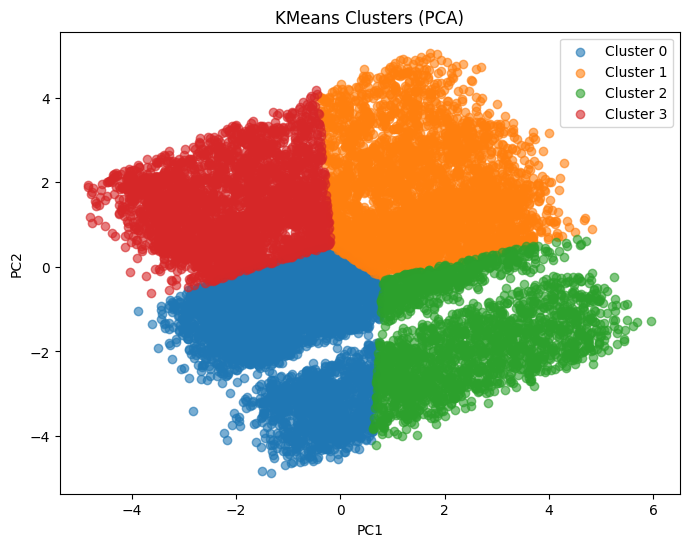

In [ ]:
# Best K select  (elbow graph use - usually 3 or 4)
best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Silhouette Score
score = silhouette_score(X_pca, df['Cluster'])
print(f"Silhouette Score: {score:.4f}")  # ≥ 0.15 comes

# Cluster Visualization
plt.figure(figsize=(8,6))
for i in range(best_k):
    mask = df['Cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {i}', alpha=0.6)
plt.legend()
plt.title('KMeans Clusters (PCA)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

            Avg_BPM  Session_Duration (hours)  Workout_Frequency (days/week)  \
Cluster                                                                        
0        143.268657                  0.651080                       3.009304   
1        152.197002                  1.088269                       5.791163   
2        129.501156                  0.994595                       5.237171   
3        164.063801                  0.691313                       3.242445   

         Experience_Level  
Cluster                    
0                0.366932  
1                2.284850  
2                1.877023  
3                0.532236  


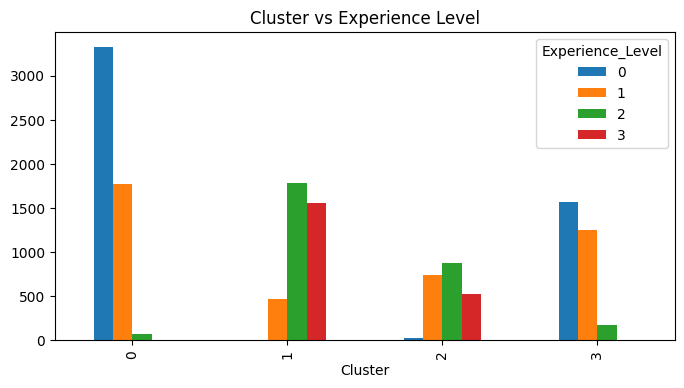

In [ ]:
# Cluster centroids analyze (average values of features in each cluster)
cluster_summary = df.groupby('Cluster')[
    ['Avg_BPM', 'Session_Duration (hours)',
     'Workout_Frequency (days/week)', 'Experience_Level']
].mean()
print(cluster_summary)

# Experience level vs Cluster
pd.crosstab(df['Cluster'], df['Experience_Level']).plot(
    kind='bar', figsize=(8,4)
)
plt.title('Cluster vs Experience Level')
plt.show()